In [2]:
from google.colab import files
uploaded = files.upload()

Saving results.txt to results.txt


In [3]:
import numpy as np
import matplotlib.pyplot as plt

errors = []
error_map = np.zeros((256,256))

error_sum = 0
error_count = 0
max_error = 0
total_cases = 0

with open("results.txt","r") as f:
    for line in f:

        A,B,approx = map(int,line.split())

        exact = A*B
        err = abs(exact-approx)

        errors.append(err)
        error_map[A][B] = err

        error_sum += err
        total_cases += 1

        if err != 0:
            error_count += 1

        if err > max_error:
            max_error = err

MED = error_sum/total_cases
NMED = MED/65025
ER = error_count/total_cases

print("Total cases:",total_cases)
print("Error Count:",error_count)
print("Error Rate (ER):",ER)
print("MED:",MED)
print("NMED:",NMED)
print("Maximum Error:",max_error)

Total cases: 65536
Error Count: 47870
Error Rate (ER): 0.730438232421875
MED: 81.9727783203125
NMED: 0.0012606348069252211
Maximum Error: 600


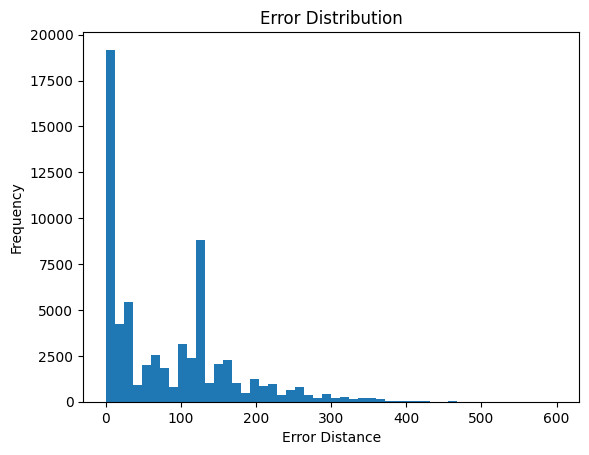

<Figure size 640x480 with 0 Axes>

In [4]:
plt.hist(errors,bins=50)
plt.title("Error Distribution")
plt.xlabel("Error Distance")
plt.ylabel("Frequency")
plt.show()
plt.savefig("error_histogram.png")

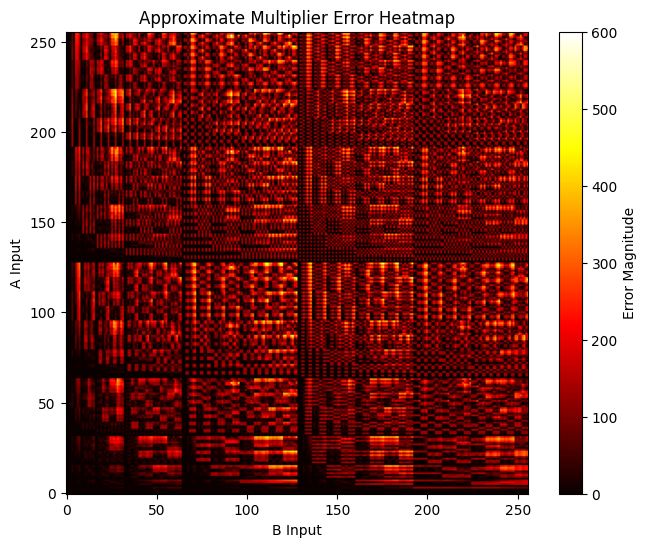

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(8,6))
plt.imshow(error_map,cmap="hot",origin="lower")
plt.colorbar(label="Error Magnitude")
plt.title("Approximate Multiplier Error Heatmap")
plt.xlabel("B Input")
plt.ylabel("A Input")
plt.show()
plt.savefig("error_heatmap.png")